# Вычислительная математика
## 4.4 Пределы и ряды

Основано на материалах Курбакова И.Л. (Институт спектроскопии РАН)

Содержание семинара:
- __Численное интегрирование на разностных схемах__
    - Общая формула симметричной разностной схемы n-го порядка 
- __Расчёт бесконечных сумм__
    - Метод прямой сшивки
    - Метод плавного обрезания
    - Метод Куммера
    - Метод Эйлера*
- __Быстрое вычисление пределов__

## Численное интегрирование на разностных схемах

Опишем методику численного расчета интеграла $\int_a^b f(x) d x$ с помощью __разностных схем в старших порядках__. В отличие от квадратур, тут нам будут нужны производные.


__Теорема.__ Пусть функция $f(x)$ аналитична в каждой точке отрезка $[a ; b]$. Тогда её интеграл можно вычислять квадратурой __на разностных схемах старшего порядка__ по формуле:

$$
\begin{gathered}
\int_a^b f(x) d x=h \sum_{j=0}^{J-1} \sum_{k=-m}^m W_{m-k}^m y_{j+k}+O\left(h^{2 m+2}\right)
\end{gathered}
$$ 

где коэффициенты не зависят от функции и задаются рекурсивными формулами:

$$
W_k^m=\sum_{n=0}^m \frac{A_{k, 2 n}^{m-n}}{2^{2 n}(2 n+1) !}
$$

$$
A_{k n}^m=\sum_{l=0}^m(-1)^{k-m} D_n^{(l)} C_{n+2 l}^{k-m+l}
$$

$$
D_n^{(j+1)}=\sum_{k=0}^{n+2 j} \sum_{l=0}^j(-1)^k D_n^{(l)} C_{n+2 l}^{k-j+l} \frac{(n+2 j-2 k)^{n+2 j+2}}{2^{n+2 j+2}(n+2 j+2) !}, \quad D_n^{(0)} \equiv 1
$$

__Примечание.__ Обратите внимание, что квадратура вылезает за сетку на отрезке $[a ; b]$! Это специфика этого метода. Про бесконечные пределы смотреть примечание ниже.

__Доказательство.__

Пусть функция $f(x)$ аналитична в каждой точке отрезка $[a ; b]$. Тогда она аналитична хотя бы немного за пределами отрезка $[a ; b]$, т. е. на некотором интервале $\left(a^{\prime} ; b^{\prime}\right)\supset[a ; b]$. Это условие нам понадобится для того чтобы использовать только __симметричные разностные схемы__ даже на границах отрезка.

Разобьем отрезок $[a ; b]$ на $J$ одинаковых кусочков и на каждом кусочке разложим $f(x)$ в ряд Тейлора в средней точке каждого кусочка, после чего вычислим интеграл на каждом кусочке. Имеем,

$$
\begin{gathered}
\int_a^b f(x) d x=\sum_{j=0}^{J-1} \int_{x_j-\Delta x}^{x_j+\Delta x} f(x) d x= \\
=\sum_{j=0}^{J-1} \sum_{n=0}^m \frac{f^{(2 n)}\left(x_j\right)}{(2 n) !} \int_{x_j-\Delta x}^{x_j+\Delta x}\left(x-x_j\right)^{2 n} d x+O\left(\Delta x^{2 m+2}\right)= \\
=\sum_{j=0}^{J-1} \sum_{n=0}^m \frac{f^{(2 n)}\left(x_j\right)}{(2 n+1) !} 2 \Delta x^{2 n+1}+O\left(\Delta x^{2 m+2}\right) .
\end{gathered}
$$ 

Где $\Delta x=(b-a) / 2 J=\cfrac{h}{2}$- половина длины кусочка, $J-$ число кусочков, $x_j=a+(2 j+1) \Delta x-$ средняя точка $j$ го кусочка, и учтено, что $\sum_{j=0}^{J-1} O(\Delta x)=O(1)$ и что интеграл в симметричных пределах от нечетных степеней $\left(x-x_j\right)^{2 n+1}$ равен нулю.

Итого получили __метод численного расчёта интеграла произвольного порядка сходимости ($2m+2$)__ , в котором нам нужны не только значения функции в узлах сетки, но и значения всех производных до $2m$ включительно в этих же узлах __с нужной точностью__.

В следующем году в семинаре 4.1 будет выведена __общая формула для симметричной разностной схемы произвольного порядка аппроксимации__. Пока её вывод можно посмотреть в файле numer.pdf в доп. материалах. Сама формула:

$$
f^{(n)}\left(x_j\right)=\frac{1}{2^n h^n} \sum_{k=0}^{n+2 m} A_{k n}^m \cdot y_{j+n+2 m-2 k}+O\left(h^{2 m+2}\right)
$$

$$
A_{k n}^m=\sum_{l=0}^m(-1)^{k-m} D_n^{(l)} C_{n+2 l}^{k-m+l}
$$

$$
D_n^{(j+1)}=\sum_{k=0}^{n+2 j} \sum_{l=0}^j(-1)^k D_n^{(l)} C_{n+2 l}^{k-j+l} \frac{(n+2 j-2 k)^{n+2 j+2}}{2^{n+2 j+2}(n+2 j+2) !}, \quad D_n^{(0)} \equiv 1
$$

Отметим, что это разностная схема __не сходится с ростом $m$!__ при фиксированном шаге. Поэтому рекомендуется брать $m$ меньше, чем точность исходных данных. Для машинной точности (аналитические функции, 16 значящих знаков) хорошее значение $m=7$.

Нам нужны только чётные производные и даже немаксимального порядка аппроксимации (т.к. для каждой из них производные домножаются на $\Delta x = \frac{h}{2}$ в каких-то степенях). Внесём нужные модификации в формулу:

$$
f^{(2 n)}\left(x_j\right)=\frac{1}{(2 \Delta x)^{2 n}} \sum_{k=0}^{2 m} A_{k, 2 n}^{m-n} \cdot y_{j+m-k}+O\left(\Delta x^{2 m-2 n+2}\right)
$$

Подставляя эту формулу в оценку интеграла, имеем:

$$
\int_a^b f(x) d x=2 \Delta x \sum_{j=0}^{J-1} \sum_{n=0}^m \sum_{k=0}^{2 m} \frac{A_{k, 2 n}^{m-n}}{2^{2 n}(2 n+1) !} \cdot y_{j+m-k}+O\left(\Delta x^{2 m+2}\right)
$$

Вводя коэфициенты 

$$
W_k^m=\sum_{n=0}^m \frac{A_{k, 2 n}^{m-n}}{2^{2 n}(2 n+1) !}
$$

получаем __квадратуру__, основанную на __разностных схемах на $2m$ точках__ (заметье, что она вылезает за отрезок интегрирования!):


$$
\begin{gathered}
\int_a^b f(x) d x&=2 \Delta x \sum_{j=0}^{J-1} \sum_{k=-m}^m W_{m-k}^m y_{j+k}+O\left(\Delta x^{2 m+2}\right)= \\
&=h \sum_{j=0}^{J-1} \sum_{k=-m}^m W_{m-k}^m y_{j+k}+O\left(h^{2 m+2}\right)
\end{gathered}
$$ 

__Примечание.__ Важно заметить, что квадратура для интеграла "__вылезает__" за пределы области интегрирования - отрезка $[a ; b]$. Это - специфика применяемых здесь разностных схем в старших порядках. Но зато, интеграл вычисляется очень быстро -$J+2 m$ обращений к функции дают ошибку $O\left(\Delta x^{2 m+2}\right)$. Так, при $m=7$ вычисление сетки значений $\exp \left(x_j\right)$ для интерграла $\int_a^b e^x d x$ машинная точность $10^{-16}$ достигается при длине кусочка $x_{j+1}-x_j=0.25$. Тогда как обычный метод Симпсона (с ошибкой $O\left(\Delta x^4\right)$ ) для достижения машинной точности требует шаг $\Delta x=0.0001$, что на три порядка меньше!

Более того, для данной квадратуры естественно можно применять алгоритм Рунге для оценки погрешности.

__Примечание.__ Отметим, что если выход сетки $\left\{x_j\right\}$ за пределы области интегрирования __недопустим (неаналитичность или бесконечные пределы)__, можно, как один из вариантов, вместо интеграла $\int_a^b f(x) d x$ вычислять интеграл $\int_0^1 f(x(t)) \dot{x}(t) d t$ с заменами, например, 

$$x(t)=a+(b-a)(1-\cos (\pi t)) / 2$$ 

или при $b=+\infty$

$$
x(t)=\frac{2 a}{(1+\cos (\pi t))}
$$

__Аналитичность__ функции $f(x(t)) \dot{x}(t)$ в каждой точке отрезка $t \in[0 ; 1]$ должна гарантироваться заменой __в обязательном порядке__. В противном случае нужно использовать другую замену.

## Расчёт бесконечных сумм
### Метод прямой сшивки

С помощью только что выведенного квадратуры можно вычислять очень большие и даже бесконечные суммы.

Преобразуем итоговую формулу в прошлом пункте к следующему виду (с учётом $\sum_{k=0}^{2 m} W_k^m=1$):

$$
\begin{gathered}
\int_a^b f(x) d x=2 \Delta x\left[\sum_{j=m}^{J-m-1} y_j+\sum_{j=-m}^{m-1} I_{j+m}^m y_j+\sum_{j=J-m}^{J+m-1}\left(1-I_{j+m-J}^m\right) y_j\right]+O\left(\Delta x^{2 m+2}\right)
\end{gathered}
$$

где опять введены новые коэффициенты

$$
I_l^m=\sum_{k=0}^l W_{2 m-k}^m
$$

Выразим сумму через интеграл:

$$
\sum_{j=m}^{J+m-1} y_j=\frac{1}{2 \Delta x} \int_a^b f(x) d x-\sum_{j=-m}^{m-1} I_{j+m}^m y_j+\sum_{j=J-m}^{J+m-1} I_{j+m-J}^m y_j + O\left(\Delta x^{2 m+1}\right)
$$

Напомним, что $y_j=f(a+(2 j+1) \Delta x), m \lesssim 7-\text { порядок схемы, а } b=a+2 J \Delta x$.

Мы видим, что каково бы ни было большим число $J$, сумма __большого__ слагаемых ( $J$ штук) выражается через сумму __малого__ числа слагаемых ( $4 m$ штук) плюс хвостовой интеграл. Иначе говоря, сделав лишь $4 m$ обращений к последовательности, можно перейти __от суммы к интегралу__. 

Ошибку перехода $O\left(\Delta x^{2 m+1}\right)$ можно опустить, когда последовательность $\left\{y_j\right\}$ меняется с $j$ медленно, в смысле, функция $f(x)$ меняется медленно на масштабе $\Delta x$. Это следует из независимости ошибки от $J$.

Теперь изложим сам метод.

Пусть нужно вычислить сумму $\sum_{j=j_0}^{j_1-1} a_j$, где величина $j_1-j_0$ может быть велика или даже равна бесконечности, а последовательность $\left\{a_j\right\}$ изменяется медленно с $j$ при больших $j$. Более точно, при $j>j_m$ характерный масштаб изменения последовательности $\left\{a_j\right\}$ больше или равен некоторому $j_{\mathrm{s}} \gg 1$.

Введём функцию $f(2 j \Delta x)=a_j, a=\left(2 j_m+1\right) \Delta x$ и $J=j_1-j_m-1$, предполагая необходимые аналитические свойства функции $f(x)$ (грубо, предполагаем работу с аналитическим продолжением $f(x)$). Тогда связь обозначений будет иметь вид $y_j=$ $a_{j+j_m-1}$, при этом $b=\left(2 j_1-1\right) \Delta x$. После такой смены обозначений:

$$
\int_a^b f(x) \frac{d x}{2 \Delta x}=\int_{-1 / 2}^{J-1 / 2} y_j d j=\int_{j_m+1 / 2}^{j_1-1 / 2} a_j d j
$$

где $a_j$ и $y_j$ мы рассматриваем, как функции непрерывного аргумента $j$. Правый интеграл таким образом по квадратуре:

$$
\begin{gathered}
\int_{j_m+1 / 2}^{j_1-1 / 2} a_j d j= \\
=\sum_{j=j_m+m+1}^{j_1-m-1} a_j+\sum_{j=j_m-m+1}^{j_m+m} I_{j+m-j_m-1}^m a_j+\sum_{j=j_1-m}^{j_1+m-1}\left(1-I_{j+m-j_1}^m\right) a_j+O\left(\Delta x^{2 m+2}\right)
\end{gathered}
$$

Ошибка $O\left(\Delta x^{2 m+2}\right)$ мала как $O\left(\Delta x / x_{\mathrm{s}}\right)^{2 m+2}$, где $x_{\mathrm{s}}$ - характерный масштаб изменения функции $f(x)$ на отрезке $[a ; b]$, включая краевые точки. В обозначениях этого параграфа $x_{\mathrm{s}}=2 j_{\mathrm{s}} \Delta x$. Отсюда  после преобразований получаем искомое выражение

$$
\begin{gathered}
\sum_{j=j_0}^{j_1-1} a_j=\int_{j_m+1 / 2}^{j_1-1 / 2} a_j d j+\sum_{j=j_0}^{j_m-m} a_j-\sum_{j=j_1}^{j_1+m-1} a_j+ \\
+\sum_{j=j_m-m+1}^{j_m+m}\left(1-I_{j+m-j_m-1}^m\right) a_j+\sum_{j=j_1-m}^{j_1+m-1} I_{j+m-j_1}^m a_j+O\left(1 / j_{\mathrm{s}}^{2 m+2}\right) .
\end{gathered}
$$

для суммы большого числа слагаемых (порядка $j_1-j_0$ штук) через хвостовой интеграл и сумму малого числа слагаемых (порядка $m$ и $j_m-j_0$ штук).

__Сумма ряда 1.__ В важном частном случае $j_0=1$ и $j_1=\infty$ формула приобретает вид

$$
\sum_{j=1}^{\infty} a_j=\int_{j_m+1 / 2}^{\infty} a_j d j+\sum_{j=1}^{j_m-m} a_j+\sum_{j=j_m-m+1}^{j_m+m}\left(1-I_{j+m-j_m-1}^m\right) a_j+O\left(1 / j_{\mathrm{s}}^{2 m+2}\right)
$$

__Сумма ряда 2.__ В другом важном частном случае $j_0=-\infty$ и $j_1=\infty$, выбирая $j_m=-\infty$, получаем __обоснование перехода от суммы к интегралу__

$$
\sum_{j=-\infty}^{\infty} a_j=\int_{-\infty}^{\infty} a_j d j+O\left(1 / j_{\mathrm{s}}^{2 m+2}\right) .
$$

для медленно меняющейся последовательности $\left\{a_j\right\}_{j=-\infty}^{\infty}$, характерный масштаб изменения которой $j_{\mathrm{s}} \gg 1$.

__Примечание.__ Если характереный масштаб изменения $j_{\mathrm{s}}$ последовательности $\left\{a_j\right\}_{j=1}^{\infty}$ составляет хотя бы несколько десятков, ошибку $O\left(1 / j_{\mathrm{s}}^{2 m+2}\right)$ уже при $m=7$ легко уложить в машинную точность.

### Метод плавного обрезания

Нижеописанный метод плавного обрезания немного более ресурсоемок, но зато весьма прост и удобен в программировании, когда необходимо вычислять многомерные бесконечные суммы.

Идея метода заключается в обрезании бесконечной суммы некоторой плавной функцией с последующим прибавлением хвостового интеграла.

Для этого вводится функцию плавного обрезания $j_{\mathrm{sm}}(x)$, которая:
- Равна единице при $x<0$.
- Равна нулю при $x>1$.
- В диапазоне $0 \leq x \leq 1$ она достаточно плавно выходит с единицы на нуль.
- Причем касание единицы в $x=0$ и нуля в $x=1$ достаточно плавное.

Приведем два примера такой функции.

1. Функция

$$
j_{\mathrm{sm}}(x)= \begin{cases}\cfrac{1,}{1+\operatorname{expsh} \frac{2 x-1}{X},} & 0 \leq x \leq 1, \\ 0, & x>1,\end{cases}
$$

в которой величина

$$
X=\frac{1}{\ln \left[\ln \frac{1-\mathrm{e}_{\mathrm{r}}}{\mathrm{e}_{\mathrm{r}}}+\sqrt{1+\ln ^2 \frac{1-\mathrm{e}_{\mathrm{r}}}{\mathrm{e}_{\mathrm{r}}}}\right]}
$$

выбирается из условия того, чтобы скачки $j_{\mathrm{sm}}(x)$ в $x=0$ и в $x=1$ заведомо укладывались в машинную точность

$$
j(1)=1-j(0)=\mathrm{e}_{\mathrm{r}} \ll 10^{-16},
$$

причем малая константа $\mathrm{e}_{\mathrm{r}}$ - внутренний параметр метода.

2. Функция
$$
j_{\mathrm{sm}}(x)=\left\{\begin{array}{cc}
\left(1-\left(2 x-x^2\right)^{2 k_1}\right)^{k_2}, & 0 \leq x \leq 1 \\
0, & x>1,
\end{array}\right.
$$

где $k_{1,2} \in \mathrm{Z}_{+}$, которая обладает касанием высокого порядка единицы при $x=0$ и нуля при $x=1$ и которая вычисляется (при заданных $k_1$ и $k_2$ ) примерно за __8 умножений__.

В любом случае функция $j_{\mathrm{sm}}((x-a) /(b-a))$ плавно выходит с единицы при $x<a$ на нуль при $x>b$, где $a<b$.

Опишем теперь сам метод.

Пусть нужно вычислить (многомерную) бесконечную сумму $\sum_{\mathbf{j}} a_{\mathbf{j}}$, где $\mathbf{j}=\left\{j_1, \ldots j_n\right\} \in \mathrm{Z}^n-n$-мерный целочисленный вектор. Считаем, что последовательность $a_{\mathrm{j}}$ при значениях модуля $|\mathrm{j}|$, превышающих некоторое $a \geq 0$, является медленной функцией вектора j: ее характерный масштаб изменения $j_{\mathrm{s}} \gg 1$.
Суть метода заключается в следующей формуле

$$
\sum_{\mathbf{j}} a_{\mathbf{j}}=\sum_{\mathbf{j}} a_{\mathbf{j}}\cdot j_{\mathrm{sm}}\left(x_{\mathbf{j}}\right)+\int_{-\infty}^{\infty} d \mathbf{j} \cdot a_{\mathbf{j}} \cdot\left(1-j_{\mathrm{sm}}\left(x_{\mathbf{j}}\right)\right),
$$

где функция, например,

$$
x_{\mathbf{j}}=\frac{|\mathbf{j}|-a}{b-a} \text { или } x_{\mathbf{j}}=\frac{|\mathbf{j}|^2-a^2}{b^2-a^2} \text { или др., }
$$

а отрезок $|\mathbf{j}| \in[a ; b]$ выбирается так, чтобы хвостовой интеграл выше брался от плавной функции (так что в пределе $j_{\mathrm{s}} \rightarrow \infty$ получается $b-a \sim j_{\mathrm{s}}$.

В этих двух формулах и выполнены следующие трюки:
- Последовательность $a_{\mathrm{j}}$ путем домножения на функцию плавного обрезания $j_{\mathrm{sm}}\left(x_{\mathbf{j}}\right)$ с ростом модуля $|\mathbf{j}|$ плавно выводится на нуль, когда $|\mathbf{j}|$ меняется от $a$ до $b$. Так что в многомерной сумме в первом слагаемом в (43) число слагаемых конечно - порядка $b^n$.
</br></br>
- В обрезывающем множителе $j_{\mathrm{sm}}\left(x_{\mathrm{j}}\right)$ монотонно возрастающая функция $x_{\mathbf{j}}$ зависит от вектора $\mathbf{j}$ плавно. То же касается последовательности $a_{\mathbf{j}}$ и самого множителя $j_{\mathrm{sm}}\left(x_{\mathbf{j}}\right)$. Это обеспечивает плавность функции под интегралом во втором слагаемом. Поэтому сам интеграл можно численно вычислять схемами старшего порядка, т. е. небольшим компьютерным ресурсом.
</br></br>
- Во втором слагаемом в (43) выполнен переход от суммы к интегралу по причине плавности подинтегральной функции. Это законно в силу __суммы ряда 2__.

Таким образом, суть метода заключается в том, чтобы быстро изменяющуюся составляющую последовательности рассчитывать прямо, а медленно изменяющуюся вычислять путем перехода от суммы к интегралу.

При $m=7$ и $j_{\mathrm{s}} \sim 20$ ошибка $O\left(1 / j_{\mathrm{s}}^{2 m+2}\right)$ перехода от суммы к интегралу в __сумме ряда 2__, она же - ошибка вычисления интеграла в последней формуле при подобранных $a$ и $b$ - обе вмещаются в машинную точность.

### Метод Куммера

Пусть ряд $\sum_{n=1}^{\infty} a_n$ сходится и сумма его равна S. Предположим, что он сходится крайне медленно и для вычисления его суммы напрямую понадобилось бы слишком много арифметических действий, что приведёт к большой случайной ошибке.

Подберем ряд $\sum_{n=1}^{\infty} b_n$ сумма которого известна $\mathrm{S}_1$, причем, этот ряд в пределе приближает наш ряд т.е. $\lim _{n \rightarrow \infty} \frac{a_n}{b_n}=\gamma \neq 0$

Представим ряд $\sum_{n=1}^{\infty} a_n$ в виде

$$
\sum_{n=1}^{\infty} a_n=\sum_{n=1}^{\infty} a_n-\gamma \cdot \sum_{n=1}^{\infty} b_n+\gamma \cdot \sum_{n=1}^{\infty} b_n=\gamma \cdot S_1+\sum_{n=1}^{\infty} a_n\left(1-\gamma \frac{b_n}{a_n}\right)
$$

Так как

$$
\lim _{n \rightarrow \infty} \frac{a_n\left(1-\gamma \cdot \frac{b_n}{a_n}\right)}{a_n}=0 \Leftrightarrow a_n\left(1-\gamma \cdot \frac{b_n}{a_n}\right)=o\left(a_n\right) 
$$

то ряд $\sum_{n=1}^{\infty} a_n\left(1-\gamma \frac{b_n}{a_n}\right)$ сходится быстрее ряда $\sum_{n=1}^{\infty} a_n$ и поэтому, вычисляя S по формуле

$$
S=\gamma \cdot S_1+\sum_{n=1}^{\infty} a_n\left(1-\gamma \frac{b_n}{a_n}\right)
$$

получаем требуемую точность $\varepsilon$ при меньшем числе шагов.

Примеры рядов с известными суммами:

$$
\begin{array}{|c|c|}
\hline \text { Ряд } & \text { Сумма } \\
\hline \sum_{n=1}^{\infty} \frac{1}{n^2} & \frac{\pi^2}{6} \\
\hline \sum_{n=1}^{\infty} \frac{1}{n^4} & \frac{\pi^4}{90} \\
\hline \sum_{n=1}^{\infty} \frac{1}{n^6} & \frac{\pi^6}{945} \\
\hline \sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n} & \ln 2 \\
\hline \sum_{n=1}^{\infty} \frac{(-1)^{n-1}}{n^2} & \frac{\pi^2}{12} \\
\hline \sum_{n=1}^{\infty} \frac{1}{n(n+1) \ldots(n+p)} & \frac{1}{p} \cdot \frac{1}{p !} \\
\hline \sum_{n=1}^{\infty} \frac{\operatorname{cos}(n x)}{n} & -\ln \left(2 \operatorname{sin} \frac{x}{2}\right) \\
\hline \sum_{n=1}^{\infty} \frac{\operatorname{cos}(n x)}{n^2} & \frac{\pi^2}{6}-\frac{\pi x}{12}+\frac{x^2}{4} \\
\hline \sum_{n=1}^{\infty} \frac{\operatorname{sin}(n x)}{n^3} & \frac{\pi^2 x}{6}-\frac{\pi x^2}{4}+\frac{x^3}{12} \\
\hline \sum_{n=1}^{\infty} \frac{\operatorname{sin}(n x)}{n} & \frac{\pi-x}{2} \\
\hline \sum_{n=1}^{\infty}(-1)^{n-1} \cfrac{1}{n} \operatorname{cos}(n x) & \ln \left(2 \operatorname{cos} \frac{x}{2}\right) \\
\hline \sum_{n=1}^{\infty}(-1)^{n-1} \cfrac{1}{n^2} \operatorname{cos}\left(\frac{n \pi x}{3}\right) & \frac{\pi^2}{36}\left(3-x^2\right) \\
\hline
\end{array}
$$

__Пример.__ Вычислить сумму ряда
$$
\sum_{n=1}^{\infty} \frac{n^2+1}{n^4+n^2+1} \operatorname{Cos}(2 n)
$$

с точностью $\varepsilon=10^{-6}$, применяя метод Куммера.

Определим количество членов, необходимое для обеспечения требуемой точности $\varepsilon=10^{-6}$.
$$
\begin{aligned}
& \left|R_k\right|=\sum_{n=k+1}^{\infty}\left|\frac{n^2+1}{n^4+n^2+1} \operatorname{Cos}(2 n)\right| \leq \sum_{n=k+1}^{\infty} \frac{n^2+1}{n^4+n^2+1}<\sum_{n=k+1}^{\infty} \frac{n^2+1}{n^2\left(n^2+1\right)}=\sum_{n=k+1}^{\infty} \frac{1}{n^2}< \\
& <\int_{k+1}^{\infty} \frac{d x}{x^2}=\frac{1}{k+1}<10^{-6}
\end{aligned}
$$

Решая последнее неравенство, получим
$$
\mathrm{k}+1>10^{-6}, \quad \mathrm{k}>10^{-6}-1 .
$$

Итак, для обеспечения точности $\varepsilon=10^{-6}$ необходимо взять примерно $10^6$ членов ряда - многовато будет.

Теперь воспользуемся вспомогательным рядом из таблицы
$$
\sum_{n=1}^{\infty} \frac{\operatorname{cos}(n x)}{n^2}=\frac{\pi^2}{6}-\frac{\pi x}{12}+\frac{x^2}{4} \text { при } \mathrm{x}=2
$$

имеем
$$
\sum_{n=1}^{\infty} \frac{\operatorname{cos}(2 n)}{n^2}=\frac{\pi^2}{6}-\frac{\pi}{6}+1 .
$$

Находим
$$
\gamma=\lim _{n \rightarrow \infty} \frac{a_n}{b_n}=\lim _{n \rightarrow \infty} \frac{\left(n^2+1\right) \operatorname{cos} 2 n \cdot n^2}{\left(n^4+n^2+1\right) \cdot \operatorname{cos} 2 n}=1
$$

Отсюда
$$
\begin{aligned}
& S=\sum_{n=1}^{\infty} \frac{n^2}{n^4+n^2+1} \cdot \operatorname{cos} 2 n=\frac{\pi^2}{6}-\frac{\pi}{6}+1+\sum_{n=1}^{\infty}\left(\frac{n^2}{n^4+n^2+1}-\frac{1}{n^2}\right) \cdot \operatorname{cos} 2 n= \\
& =\frac{\pi^2}{6}-\frac{\pi}{6}+1-\sum_{n=1}^{\infty} \frac{\operatorname{cos} 2 n}{n^2\left(n^4+n^2+1\right)} .
\end{aligned}
$$

Определим количество членов полученного ряда, необходимое для обеспечения точности $\varepsilon$.
$$
\left|R_k\right|=\left|\sum_{x=k+1}^{\infty} \frac{\operatorname{cos} 2 n}{n^2\left(n^4+n^2+1\right)}\right| \leq \sum_{n=k+1}^{\infty} \frac{1}{n^2\left(n^4+n^2+1\right)}<=\sum_{n=k+1}^{\infty} \frac{1}{n^6}<\int_{k+1}^{\infty} \frac{d x}{x^6}=\frac{1}{5(k+1)^5}<10^{-6} .
$$

Откуда находим, что искомая точность достигается при $\mathrm{k} \geq 10$ слагаемых. Можно посчитать и в уме, как говорится.

### Метод Эйлера* (доделать)

## Быстрое вычисление пределов

Пусть надо численно вычислить предел

$$
\lim _{x \rightarrow 0} f(x) \equiv A,
$$

где $x$ и $f(x)$ - действительные.
Будем рассматривать случай, когда следующие три условия на функцию $f(x)$ выполнены.
- Функция $f(x)=f(-x)$ - четная. (всегда можно свести к этому случаю, см. ниже)
- Значение предела $A$ - конечно. Иначе говоря, точка $x=0$ - выколотая: в ней возможна неопределенность, типа, например, $0 / 0$.
- Если разрыв $f(x)$ в выколотой точке $x=0$ устранить (по непрерывности, как обычно), то полученнная функция является аналитической в $x=0$.

На языке ряда Тейлора эти три условия означают, что

$$
f(x)=a_0+\frac{a_2}{2 !} x^2+\frac{a_4}{4 !} x^4+\frac{a_6}{6 !} x^6+\ldots, \quad 0<|x|<x_{\mathrm{m}},
$$

где коэффициенты $a_{2 k}$ - действительны, а $x_{\mathrm{m}}$ - радиус сходимости. При этом $a_0=A-$ конечное число.

Следующие три случая подпадают по этот случай.

a) __Обычный (двусторонний) предел__

$$
\lim _{t \rightarrow a} y(t)=\lim _{x \rightarrow 0} \frac{y(a+x)+y(a-x)}{2},
$$

где функция $y(t)$ после устранения разрыва в выколотой точке $t=a$ является аналитической в $t=a$. Пример функции: $y(t)=\sin t /\left(e^t-\right.$ $1)$.

б) __Односторонний предел__

$$
\lim _{t \rightarrow a+0} y(t)=\lim _{x \rightarrow 0} y\left(a+x^2\right),
$$

в котором функция $y\left(a+x^2\right)$, как зависящая от переменной $x$, аналитична в $x=0$ (если разрыв в $x=0$ устранен). Пример функции: $y(t)=e^t$ при $t>0$ и $y=0$ при $t<0$.

в) __Односторонний предел с корневой особенностью__

$$
\lim _{t \rightarrow a+0} y(t)=\lim _{x \rightarrow 0} y\left(a+x^{2 K}\right),
$$

где $K>1$ - целое. Здесь (после устранения разрыва в $x=0$ ) функция $f(x)$, как зависящая от $x$, аналитична в $x=0$. Пример функции для $K=3: y(t)=\left(\exp \left(t^{1 / 3}\right)-\sqrt{1+t^{1 / 3}}\right) t^{-1 / 3}$.

Важно заметить, что случай (а) включен в (б), а (б) - в (в). Однако классификацию (а)-(в) проводить надо. Иначе точность взятия предела сильно падает. В самом деле, случай (б) (тем более, (в)) дает неопределенность $0^2 / 0^2$ - более сильную, чем $0 / 0$ в случае (а).

Вернемся к численному взятию предела, в которой функция $f(x)$ дается рядом Тейлора. Идея взятия предела заключается в следующем.

1. Набросать эквидистантную сетку вблизи точки $x=0$ с некоторым шагом $\Delta x$ так, чтобы проблемная точка $x=0$ прошла где-то подальше от узлов сетки.
2. Вычислить значения функции $f(x)$ в этих узлах сетки, а затем найти ближайший к $x=0$ узел сетки, и разложившись в ряд Тейлора в этом узле, сделать интерполяцию в $x=0$.

Вот, как выглядит эта процедура алгоритмически.

Рассматривается __симметризованная__ сетка

$$
\begin{gathered}
y_0=y_{-1}=f( \pm \Delta x / 2),\\ y_1=y_{-2}=f( \pm 3 \Delta x / 2), \\
\quad \ldots\\ y_{j_0-1}=y_{-j_0}=f\left( \pm\left(2 j_0-1\right) \Delta x / 2\right),
\end{gathered}
$$

в которой $j_0$ - число обращений к функции $f(x)$. Симметризация имеет два преимущества: вдвое снижает число обращений к $f(x)$ (с $2 j_0-1$ до $j_0$ ) и использует случай, в котором проблемная точка $x=0$ находится на максимальном расстоянии от узлов сетки, т. е. посередине.

В качестве ближайшего выбирается, например, узел $x_0=\Delta x / 2$. Тогда расстояние $x-x_0 \equiv h$ от $x_0$ до проблемной точки $x=0$ равняется $h=-\Delta x / 2$. В самом деле, складывая $x_0+h=0-$ получаем нуль, т. е. точку $x=0$, в которой берется предел.

Тогда, очевидно, значение $A$ предела функции $f(x)$ в точке $x=$ 0 дается рядом Тейлора

$$
A=f\left(x_0\right)+f^{\prime}\left(x_0\right) h+f^{\prime \prime}\left(x_0\right) \frac{h^2}{2}+f^{\prime \prime \prime}\left(x_0\right) \frac{h^3}{6}+\ldots+f^{(N)}\left(x_0\right) \frac{h^N}{N !}+O\left(h^{N+1}\right) \text {. }
$$

Здесь использовано равенство $f\left(x_0+h\right)=f(0)=A$, в котором учтено, что $x_0+h=0$, а устранимый разрыв $f(x)$ в $x=0$ устранен по непрерывности.

Наконец, воспользовавшись формулой для приближения проиводной произвольным порядком, после преобразований приходим к окончательной формуле для предела $f(x)$ в $x=0$ :

$$
\lim _{x \rightarrow 0} f(x)=\sum_{n=0}^N \sum_{k=0}^{2 m+n^{\prime}(n)} A_{k n}^{m-\left(n-n^{\prime}(n)\right) / 2} \frac{(-1)^n}{4^n n !} y_{2 m+n^{\prime}(n)-2 k}+O\left(\Delta x^{2 m+2}\right) .
$$

Здесь порядок схемы $m=0,1,2,3, \ldots$ и шаг $\Delta x>0$ - внутренние параметры метода, $N$ - максимальный учитываемый порядок в ряде Тейлора, причем $1 \ll N \leq 2 m+1, n^{\prime}(n)=0$ при четном $n$ и $n^{\prime}(n)=1$ при нечетном $n$, коэффициенты $A_{k n}^m$ даются формулой в начале блокнота, сетка $\left\{y_j\right\}$, где $j=1-j_0, 2-j_0, 3-j_0, \ldots j_0-1$ определена выше и симметризована, точка $y_{-j_0}$ не используется, а $j_0=2 m+2$ - число расчетных точек, оно же - число необходимых обращений к функции $f(x)$.

## Домашнее задание

__Задача 1.__

Рассчитать с машинной точностью интеграл с неопределенностью $\int_{-1}^1 d x \sin (x / 2) /\left(e^x-1\right)$ квадратурой на разностных схемах.

In [2]:
import numpy as np
from scipy.integrate import simpson, quad

def f(x):
    return np.sin(x/2)/(np.exp(x) - 1)

delta = 0.0000000000000001
quad(f, -1, - delta)[0] + quad(f, delta, 1)[0]

1.013039236232626

In [3]:
x = np.linspace(-1, 1, 1000000)  # для машинной точности x = 0.0001
y = f(x)
simpson(y, x)

1.013039236232626

In [160]:
# на разностных схемах

def D(j, n):
    d = 0
    if j == 0:
        d = 1
        return d
    j = j-1
    for k in range(0, n + 2*j + 1):
        for l in range(0, j+1):
            d += ((-1)**k) * D(l, n) * C(k-j+l, n+2*l) * ((n+2*j-2*k)**(n+2*j+2)) / ((2**(n+2*j+2))*np.math.factorial(n+2*j+2))
    return d
    
def C(k, n):
    if (k < 0) or (k > n):
        return 0
    n_ = np.math.factorial(n)
    k_ = np.math.factorial(k)
    n_k_ = np.math.factorial(n-k)
    return (n_/(k_ * n_k_))

def A(m, k, n):
    a = 0
    for l in range(0, m+1):
        a += (-1)**(k-m) * D(l, n) * C(k-m+l, n+2*l)
    return a

def W(m, k):
    w = 0
    for n in range(0, m+1):
        w += A(m-n, k, 2*n)/((2**(2*n))*np.math.factorial(2*n + 1))
    return w

def I(m, l):
    i = 0
    for k in range(0, l+1):
        i += W(m, 2*m-k)
    return i

In [6]:
J = 10
a = -1
b = 1
m = 7
h = (b-a)/J  # для машинной точности x = 0.25
I = 0
for j in range(0, J):
    for k in range(-m, m+1):
        I += W(m, m-k) * f(a + (2*(j+k) + 1)*(h/2))
I = I*h

I

1.0130392362326257

In [161]:
# save coefficients to arrays
a = 30

Ckn = np.array([[C(k, n) for n in range(a*10)] for k in range(a*10)])
factorial = np.array([np.math.factorial(i) for i in range(a*10)])
Djn = np.zeros((a, 2*a))

def Dk(j, n):
    d = 0
    if j == 0:
        d = 1
        return d
    j = j-1
    for k in range(0, n + 2*j + 1):
       for l in range(0, j+1):
            d += ((-1)**k) * Djn[l, n] * Ckn[k-j+l, n+2*l] * ((n+2*j-2*k)**(n+2*j+2)) / ((2**(n+2*j+2))*factorial[n+2*j+2])
    return d

Djn[0,:] = np.ones(2*a)
for j in range(0, a):
    for n in range(0, 2*a):
        Djn[j, n] = Dk(j, n)

Amkn = np.zeros((a, 2*a, 2*a))
def A(m, k, n):
    a = 0
    for l in range(0, m+1):
        a += (-1)**(k-m) * Djn[l, n] * Ckn[k-m+l, n+2*l]
    return a

for m in range(0, a):
    for k in range(0, 2*a):
        for n in range(0, 2*a):
            Amkn[m, k, n] = A(m, k, n)
            
Wmk = np.zeros((a, 2*a))
def W(m, k):
    w = 0
    for n in range(0, m+1):
        w += Amkn[m-n, k, 2*n]/((2**(2*n))*factorial[2*n + 1])
    return w

for m in range(0, a):
    for k in range(0, 2*a):
        Wmk[m, k] = W(m, k)
        
def I(m, l):
    i = 0
    for k in range(0, l+1):
        i += Wmk[m, 2*m-k]
        return i
    
Iml = np.zeros((a, a))
for m in range(0, a):
    for l in range(0, a):
        Iml[m, l] = I(m, l)


In [7]:
# now faster
J = 10
a = -1
b = 1
m = 7
h = (b-a)/J  # для машинной точности x = 0.25
I = 0
for j in range(0, J):
    for k in range(-m, m+1):
        I += Wmk[m, m-k] * f(a + (2*(j+k) + 1)*(h/2))
I = I*h

I

1.0130392362326257

## __Задача 2.__

Используя методику прямой сшивки при взятии сумм рядов, рассчитать постоянную $\gamma_E$ Эйлера-Маскерони с ошибкой в 13 знаке по формуле $\gamma_E=$ $\lim _{n \rightarrow \infty}(1+1 / 2+1 / 3+1 / 4+\ldots+1 / n-\ln n)$

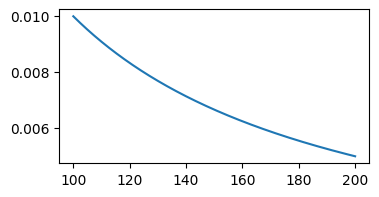

In [9]:
import matplotlib.pyplot as plt
t = np.linspace(100, 200, 1000)
plt.figure(figsize=(4, 2))
plt.plot(t, 1/t)

In [21]:
m = 8
jm = 500000000

In [22]:
def aj(n):
    return (1/n - np.log(n/(n-1)))

# S1 = 1 + np.sum(np.array([aj(x) for x in range(2, jm-m+1)]))
# S2 = np.sum(np.array([((1 - I(m, j+m-jm-1))*aj(j)) for j in range(jm-m+1, jm+m+1)]))
# I = quad(aj, jm + 1/2, float('inf'))
# I, S1, S2

In [23]:
I = quad(aj, jm + 1/2, float('inf'))
S2 = np.sum(np.array([((1 - Iml[m, j+m-jm-1])*aj(j)) for j in range(jm-m+1, jm+m+1)]))
I, S2

((-4.8784264199929726e-14, 9.14555171361593e-14), 9.050218802253126e-16)

In [24]:
S1 = 1 + np.sum(np.array([1/x for x in range(2, jm-m+1)])) - np.log(jm-m)
S1

0.5772156659017185

In [39]:
# m = 10
# jm = 50000
# I = quad(aj, jm + 1/2, float('inf'))
# S2 = np.sum(np.array([((1 - Iml[m, j+m-jm-1])*aj(j)) for j in range(jm-m+1, jm+m+1)]))
# I, S2

In [40]:
# S1 = 1 + np.sum(np.array([1/x for x in range(2, jm-m+1)])) - np.log(jm-m)
# S1+S2+I[0]

In [41]:
# gE = I[0] + (S1 + S2)
# gE, 0.57721566490153286060  #0.577215674902301

## __Задача 3.__

Вычислить сумму ряда
$$
\sum_{n=1}^{\infty} \frac{n^2+1}{n^4+n^2+1} \operatorname{сos}(2 n)
$$

с точностью $\varepsilon=10^{-6}$, применяя метод Куммера.

In [121]:
import numpy as np
def f(x):
    return (np.cos(2*x)/(x**2 * (x**4 + x**2 + 1)))

s1 = 0
for i in range(1, 15):
    s1 += f(i)

((np.pi)**2)/6 - np.pi/6 + 1 - s1

2.266728526716446

## __Задача 4.__

Взять предел 

$$\lim _{x \rightarrow 0} \frac{y(x)-1}{x}$$

где 

$$
y(x)= \begin{cases}\operatorname{ch} \sqrt{|x|}, & x>0 \\ \cos \sqrt{|x|}, & x<0\end{cases}
$$


Поиграться с выбором шага.

C:\Users\lliza\AppData\Local\Temp\ipykernel_16684\3699485458.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (y-1)/x


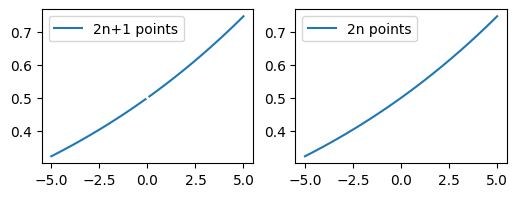

In [199]:
def f(x):
    if (x >= 0):
        y = np.cosh((np.abs(x))**(1/2))
    if (x < 0):
        y = np.cos((np.abs(x))**(1/2))
    return (y-1)/x

xx = np.linspace(-5, 5, 101)
yy = np.array([])
for x in xx:
    yy = np.append(yy, f(x))

plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.plot(xx, yy, label='2n+1 points');
plt.legend()

plt.subplot(1, 2, 2)
xx = np.linspace(-5, 5, 100)
yy = np.array([])
for x in xx:
    yy = np.append(yy, f(x))
plt.plot(xx, yy, label='2n points');
plt.legend()

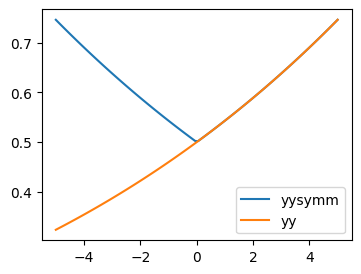

In [200]:
yysymm = np.concatenate((np.flip(yy[50:100]), yy[50:100]))

plt.figure(figsize=(4, 3))
plt.plot(xx, yysymm, label=('yysymm'));
plt.plot(xx, yy, label=('yy'));
plt.legend()

In [201]:
xx = np.linspace(-5, 5, 100)
m = 10
N = 2*m
h = 10/(2*xx.shape[0])

def y(j):
    if (j < 0):
        return f((2*(np.abs(j)) - 1)*h)
    return f((2*j + 1)*h)

y(30), y(-31)

(0.6407315658654443, 0.6407315658654443)

In [202]:
limfx = 0
for n in range(N+1):
    for k in range(2*m + n%2):
        limfx += Amkn[(m - int((n-n%2)/2)), k, n] * (-1)**n * y(2*m + n%2 - 2*k) / (4**n * np.math.factorial(n))

limfx

0.5014124627749217

In [210]:
# при разном шаге

for z in range(1, 9):
    xx = np.linspace(-5, 5, 10**z)
    m = 10
    N = 2*m
    h = 10/(2*xx.shape[0])

    def y(j):
        if (j < 0):
            return f((2*(np.abs(j)) - 1)*h)
        return f((2*j + 1)*h)

    limfx = 0
    for n in range(N+1):
        for k in range(2*m + n%2):
            limfx += Amkn[(m - int((n-n%2)/2)), k, n] * (-1)**n * y(2*m + n%2 - 2*k) / (4**n * np.math.factorial(n))

    print('step=', 2*h, 'lim f(x) = ', limfx)

step= 1.0 lim f(x) =  0.5141219204030372
step= 0.1 lim f(x) =  0.5014124627749217
step= 0.01 lim f(x) =  0.500141247285965
step= 0.001 lim f(x) =  0.5000141254681201
step= 0.0001 lim f(x) =  0.5000014132856546
step= 1e-05 lim f(x) =  0.5000001420830837
step= 1e-06 lim f(x) =  0.5000000150674455
step= 1e-07 lim f(x) =  0.5000000015112278


### Метод Куммера

__Пример.__ Вычислить сумму ряда
$$
\sum_{n=1}^{\infty} \frac{n^2+1}{n^4+n^2+1} \operatorname{Cos}(2 n)
$$

с точностью $\varepsilon=10^{-6}$, применяя метод Куммера.

Определим количество членов, необходимое для обеспечения требуемой точности $\varepsilon=10^{-6}$.
$$
\begin{aligned}
& \left|R_k\right|=\sum_{n=k+1}^{\infty}\left|\frac{n^2+1}{n^4+n^2+1} \operatorname{Cos}(2 n)\right| \leq \sum_{n=k+1}^{\infty} \frac{n^2+1}{n^4+n^2+1}<\sum_{n=k+1}^{\infty} \frac{n^2+1}{n^2\left(n^2+1\right)}=\sum_{n=k+1}^{\infty} \frac{1}{n^2}< \\
& <\int_{k}^{\infty} \frac{d x}{x^2}=\frac{1}{k}<10^{-6}
\end{aligned}
$$

Решая последнее неравенство, получим
$$
\mathrm{k}>10^{6} .
$$

Итак, для обеспечения точности $\varepsilon=10^{-6}$ необходимо взять примерно $10^6$ членов ряда - многовато будет.

Теперь воспользуемся вспомогательным рядом из таблицы
$$
\sum_{n=1}^{\infty} \frac{\operatorname{cos}(n x)}{n^2}=\frac{\pi^2}{6}-\frac{\pi x}{12}+\frac{x^2}{4} \text { при } \mathrm{x}=2
$$

имеем
$$
\sum_{n=1}^{\infty} \frac{\operatorname{cos}(2 n)}{n^2}=\frac{\pi^2}{6}-\frac{\pi}{6}+1 .
$$

Находим
$$
\gamma=\lim _{n \rightarrow \infty} \frac{a_n}{b_n}=\lim _{n \rightarrow \infty} \frac{\left(n^2+1\right) \operatorname{cos} 2 n \cdot n^2}{\left(n^4+n^2+1\right) \cdot \operatorname{cos} 2 n}=1
$$

Отсюда
$$
\begin{aligned}
& S=\sum_{n=1}^{\infty} \frac{n^2}{n^4+n^2+1} \cdot \operatorname{cos} 2 n=\frac{\pi^2}{6}-\frac{\pi}{6}+1+\sum_{n=1}^{\infty}\left(\frac{n^2}{n^4+n^2+1}-\frac{1}{n^2}\right) \cdot \operatorname{cos} 2 n= \\
& =\frac{\pi^2}{6}-\frac{\pi}{6}+1-\sum_{n=1}^{\infty} \frac{\operatorname{cos} 2 n}{n^2\left(n^4+n^2+1\right)} .
\end{aligned}
$$

Определим количество членов полученного ряда, необходимое для обеспечения точности $\varepsilon$.
$$
\left|R_k\right|=\left|\sum_{x=k+1}^{\infty} \frac{\operatorname{cos} 2 n}{n^2\left(n^4+n^2+1\right)}\right| \leq \sum_{n=k+1}^{\infty} \frac{1}{n^2\left(n^4+n^2+1\right)}<=\sum_{n=k+1}^{\infty} \frac{1}{n^6}<\int_{k}^{\infty} \frac{d x}{x^6}=\frac{1}{5(k)^5}<10^{-6} .
$$

Откуда находим, что искомая точность достигается при $\mathrm{k} \geq 10$ слагаемых. Можно посчитать и в уме, как говорится.